Problem 1a)

Mounted at /content/drive


<ipython-input-1-0d676e39114d>:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({'yes': 1, 'no': 0}, inplace=True)
<ipython-input-1-0d676e39114d>:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0}, inplace=True)


Epoch 500/10000, Training Loss: 23839727681536.0000, Validation Loss: 28534191947776.0000
Epoch 1000/10000, Training Loss: 20146175344640.0000, Validation Loss: 24299381456896.0000
Epoch 1500/10000, Training Loss: 15527619592192.0000, Validation Loss: 18952308654080.0000
Epoch 2000/10000, Training Loss: 11171735273472.0000, Validation Loss: 13836387090432.0000
Epoch 2500/10000, Training Loss: 7801891979264.0000, Validation Loss: 9824129515520.0000
Epoch 3000/10000, Training Loss: 5637172363264.0000, Validation Loss: 7197862395904.0000
Epoch 3500/10000, Training Loss: 4426484416512.0000, Validation Loss: 5718370418688.0000
Epoch 4000/10000, Training Loss: 3729241145344.0000, Validation Loss: 4907484577792.0000
Epoch 4500/10000, Training Loss: 3220682571776.0000, Validation Loss: 4399424339968.0000
Epoch 5000/10000, Training Loss: 2776348229632.0000, Validation Loss: 3987669254144.0000
Epoch 5500/10000, Training Loss: 2387016417280.0000, Validation Loss: 3616029278208.0000
Epoch 6000/100

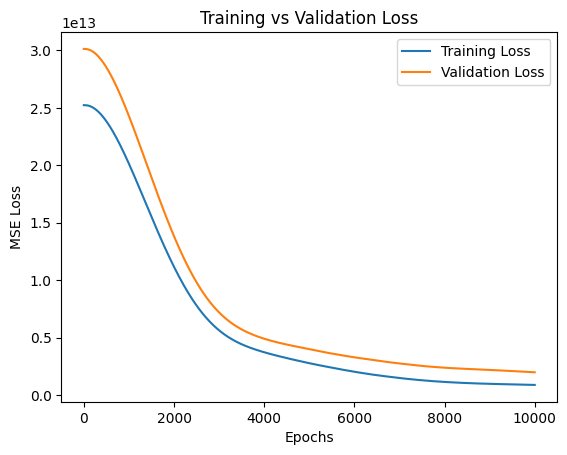

Final Validation Loss: 1983234703360.0000
Total Training Time: 13.90 seconds


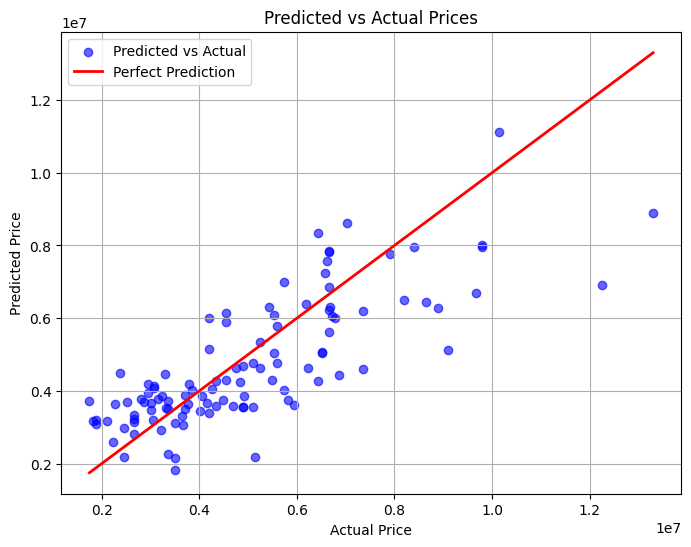

R-squared (Validation): 0.6076


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time  # For tracking runtime

from google.colab import drive
drive.mount('/content/drive')

# Load the dataset from Google Drive
csv_path = "/content/drive/My Drive/Housing.csv"
data = pd.read_csv(csv_path)

# 'Yes/No' to 1/0
data.replace({'yes': 1, 'no': 0}, inplace=True)

# 'Furnished/Semi-Furnished/Unfurnished' to 2/1/0
data.replace({'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0}, inplace=True)

# Split features and target
X = data.drop(columns=["price"]).values
y = data["price"].values

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert data to PyTorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

# Define the neural network model
class HousingNN(nn.Module):
    def __init__(self, input_dim):
        super(HousingNN, self).__init__()
        self.hidden = nn.Linear(input_dim, 8)  # Hidden layer with 8 nodes
        self.output = nn.Linear(8, 1)         # Output layer for regression

    def forward(self, x):
        x = torch.relu(self.hidden(x))       # ReLU activation for the hidden layer
        x = self.output(x)                   # No activation for output layer (regression)
        return x

# Initialize the model
input_dim = X_train.shape[1]
model = HousingNN(input_dim)

# Define the loss function and optimizer
criterion = nn.MSELoss()  # Mean Squared Error loss
optimizer = optim.Adam(model.parameters(), lr=0.1)

# Training loop
num_epochs = 10000
train_losses = []
val_losses = []

start_time = time.time()  # Start the timer

for epoch in range(num_epochs):
    # Training phase
    model.train()
    optimizer.zero_grad()
    y_pred_train = model(X_train)
    train_loss = criterion(y_pred_train, y_train)
    train_loss.backward()
    optimizer.step()
    train_losses.append(train_loss.item())

    # Validation phase
    model.eval()
    with torch.no_grad():
        y_pred_val = model(X_val)
        val_loss = criterion(y_pred_val, y_val)
        val_losses.append(val_loss.item())

    # Print loss every 500 epochs
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {train_loss.item():.4f}, Validation Loss: {val_loss.item():.4f}")

end_time = time.time()  # End the timer

# Calculate total runtime
total_runtime = end_time - start_time

# Plot training and validation loss
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

# Evaluate the model on validation data
model.eval()
with torch.no_grad():
    final_val_loss = criterion(model(X_val), y_val).item()
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Total Training Time: {total_runtime:.2f} seconds")

# Visualize predictions vs actual values
y_pred_val = model(X_val).detach().numpy()
y_val_np = y_val.numpy()

plt.figure(figsize=(8, 6))
plt.scatter(y_val_np, y_pred_val, color="blue", alpha=0.6, label="Predicted vs Actual")
plt.plot([y_val_np.min(), y_val_np.max()], [y_val_np.min(), y_val_np.max()], color="red", linewidth=2, label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices")
plt.legend()
plt.grid(True)
plt.show()

# Calculate and print R-squared for validation data
ss_total = ((y_val - y_val.mean()) ** 2).sum().item()
ss_residual = ((y_val - torch.tensor(y_pred_val)) ** 2).sum().item()
r_squared = 1 - (ss_residual / ss_total)
print(f"R-squared (Validation): {r_squared:.4f}")


Problem 1b)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<ipython-input-4-8de77d6fa35d>:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({'yes': 1, 'no': 0}, inplace=True)
<ipython-input-4-8de77d6fa35d>:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0}, inplace=True)


Epoch 500/10000, Training Loss: 25232779771904.0000, Validation Loss: 30127593357312.0000
Epoch 1000/10000, Training Loss: 25193223290880.0000, Validation Loss: 30080958988288.0000
Epoch 1500/10000, Training Loss: 25029773361152.0000, Validation Loss: 29888901808128.0000
Epoch 2000/10000, Training Loss: 24648762785792.0000, Validation Loss: 29441734475776.0000
Epoch 2500/10000, Training Loss: 23968759152640.0000, Validation Loss: 28643881385984.0000
Epoch 3000/10000, Training Loss: 22930677301248.0000, Validation Loss: 27425320730624.0000
Epoch 3500/10000, Training Loss: 21505517813760.0000, Validation Loss: 25750348496896.0000
Epoch 4000/10000, Training Loss: 19701514108928.0000, Validation Loss: 23625530867712.0000
Epoch 4500/10000, Training Loss: 17570087305216.0000, Validation Loss: 21106656280576.0000
Epoch 5000/10000, Training Loss: 15209386213376.0000, Validation Loss: 18303474991104.0000
Epoch 5500/10000, Training Loss: 12762663092224.0000, Validation Loss: 15378023448576.0000


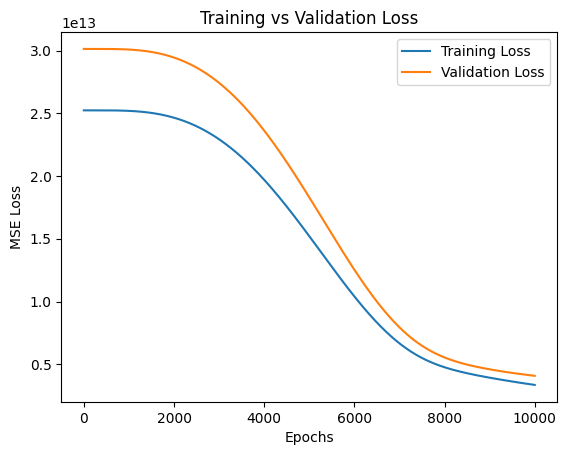

Final Validation Loss: 4075932090368.0000
Total Training Time: 34.37 seconds


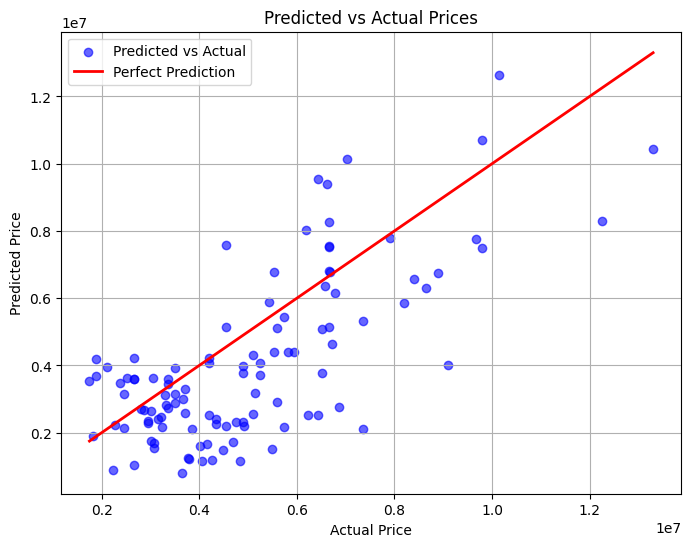

R-squared (Validation): 0.1936


In [4]:
# Same initialization so that this section can be run separately
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time  # For tracking runtime

from google.colab import drive
drive.mount('/content/drive')

# Load the dataset from Google Drive
csv_path = "/content/drive/My Drive/Housing.csv"
data = pd.read_csv(csv_path)

# 'Yes/No' to 1/0
data.replace({'yes': 1, 'no': 0}, inplace=True)

# 'Furnished/Semi-Furnished/Unfurnished' to 2/1/0
data.replace({'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0}, inplace=True)

# Split features and target
X = data.drop(columns=["price"]).values
y = data["price"].values

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert data to PyTorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

# Define the neural network model with additional hidden layers
class HousingNN(nn.Module):
    def __init__(self, input_dim):
        super(HousingNN, self).__init__()
        self.hidden1 = nn.Linear(input_dim, 8)   # First hidden layer with 8 nodes
        self.hidden2 = nn.Linear(8, 7)          # Second hidden layer with 7 nodes
        self.hidden3 = nn.Linear(7, 5)          # Third hidden layer with 5 nodes
        self.output = nn.Linear(5, 1)           # Output layer for regression

    def forward(self, x):
        x = torch.relu(self.hidden1(x))         # ReLU activation for the first hidden layer
        x = torch.relu(self.hidden2(x))         # ReLU activation for the second hidden layer
        x = torch.relu(self.hidden3(x))         # ReLU activation for the third hidden layer
        x = self.output(x)                      # No activation for output layer (regression)
        return x

# Initialize the model with the updated architecture
input_dim = X_train.shape[1]
model = HousingNN(input_dim)

# Define the loss function and optimizer
criterion = nn.MSELoss()  # Mean Squared Error loss
optimizer = optim.Adam(model.parameters(), lr=0.0008)

# Training loop
num_epochs = 10000
train_losses = []
val_losses = []

start_time = time.time()  # Start the timer

for epoch in range(num_epochs):
    # Training phase
    model.train()
    optimizer.zero_grad()
    y_pred_train = model(X_train)
    train_loss = criterion(y_pred_train, y_train)
    train_loss.backward()
    optimizer.step()
    train_losses.append(train_loss.item())

    # Validation phase
    model.eval()
    with torch.no_grad():
        y_pred_val = model(X_val)
        val_loss = criterion(y_pred_val, y_val)
        val_losses.append(val_loss.item())

    # Print loss every 500 epochs
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {train_loss.item():.4f}, Validation Loss: {val_loss.item():.4f}")

end_time = time.time()  # End the timer

# Calculate total runtime
total_runtime = end_time - start_time

# Plot training and validation loss
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

# Evaluate the model on validation data
model.eval()
with torch.no_grad():
    final_val_loss = criterion(model(X_val), y_val).item()
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Total Training Time: {total_runtime:.2f} seconds")

# Visualize predictions vs actual values
y_pred_val = model(X_val).detach().numpy()
y_val_np = y_val.numpy()

plt.figure(figsize=(8, 6))
plt.scatter(y_val_np, y_pred_val, color="blue", alpha=0.6, label="Predicted vs Actual")
plt.plot([y_val_np.min(), y_val_np.max()], [y_val_np.min(), y_val_np.max()], color="red", linewidth=2, label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices")
plt.legend()
plt.grid(True)
plt.show()

# Calculate and print R-squared for validation data
ss_total = ((y_val - y_val.mean()) ** 2).sum().item()
ss_residual = ((y_val - torch.tensor(y_pred_val)) ** 2).sum().item()
r_squared = 1 - (ss_residual / ss_total)
print(f"R-squared (Validation): {r_squared:.4f}")


Problem 2)

Epoch 100/1000, Training Loss: 0.5522, Validation Loss: 0.5445
Epoch 200/1000, Training Loss: 0.3937, Validation Loss: 0.3873
Epoch 300/1000, Training Loss: 0.2832, Validation Loss: 0.2763
Epoch 400/1000, Training Loss: 0.2145, Validation Loss: 0.2073
Epoch 500/1000, Training Loss: 0.1714, Validation Loss: 0.1645
Epoch 600/1000, Training Loss: 0.1431, Validation Loss: 0.1370
Epoch 700/1000, Training Loss: 0.1232, Validation Loss: 0.1184
Epoch 800/1000, Training Loss: 0.1086, Validation Loss: 0.1053
Epoch 900/1000, Training Loss: 0.0974, Validation Loss: 0.0958
Epoch 1000/1000, Training Loss: 0.0885, Validation Loss: 0.0886


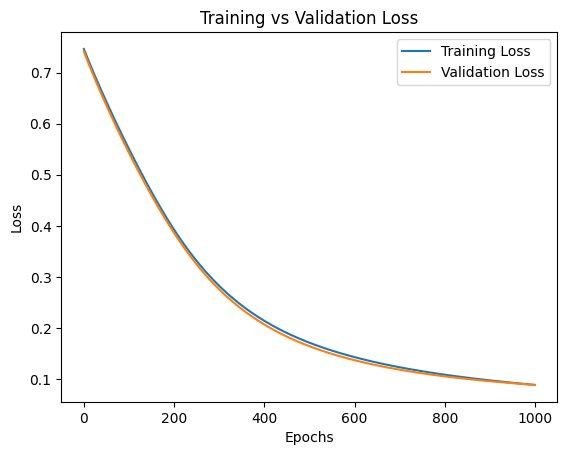

Validation Accuracy: 0.9737
Precision: 0.9857
F1 Score: 0.9787


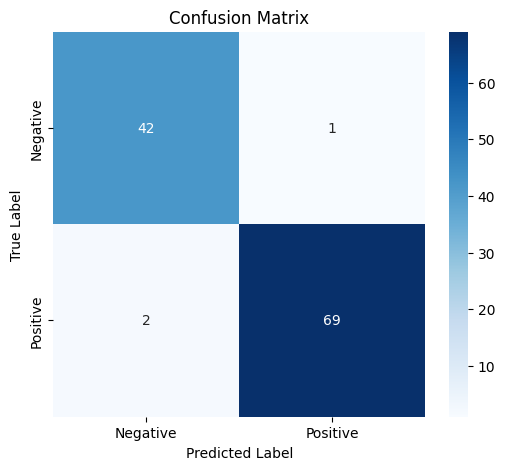

In [37]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Breast Cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target  # Features and labels

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Convert the data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # Add a dimension for compatibility
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

# Define the neural network model
class BreastCancerNN(nn.Module):
    def __init__(self, input_dim):
        super(BreastCancerNN, self).__init__()
        self.hidden = nn.Linear(input_dim, 32)  # Hidden layer with 32 nodes
        self.output = nn.Linear(32, 1)         # Output layer for binary classification

    def forward(self, x):
        x = torch.relu(self.hidden(x))        # ReLU activation for the hidden layer
        x = torch.sigmoid(self.output(x))     # Sigmoid activation for binary classification
        return x

# Initialize the model
input_dim = X_train_tensor.shape[1]
model = BreastCancerNN(input_dim)

# Define the loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss for classification
optimizer = optim.Adam(model.parameters(), lr=0.0002)

# Training loop
num_epochs = 1000
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    optimizer.zero_grad()
    y_pred_train = model(X_train_tensor)
    train_loss = criterion(y_pred_train, y_train_tensor)
    train_loss.backward()
    optimizer.step()
    train_losses.append(train_loss.item())

    # Validation phase
    model.eval()
    with torch.no_grad():
        y_pred_val = model(X_val_tensor)
        val_loss = criterion(y_pred_val, y_val_tensor)
        val_losses.append(val_loss.item())

    # Print loss every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {train_loss.item():.4f}, Validation Loss: {val_loss.item():.4f}")

# Plot training and validation loss
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

# Evaluate the model on validation data
model.eval()
with torch.no_grad():
    y_pred_val = model(X_val_tensor)
    y_pred_classes = (y_pred_val > 0.5).float()  # Convert probabilities to binary predictions
    accuracy = (y_pred_classes == y_val_tensor).float().mean().item()
    print(f"Validation Accuracy: {accuracy:.4f}")

# Generate confusion matrix
y_true = y_val_tensor.numpy().flatten()  # Ground truth labels
y_pred = y_pred_classes.numpy().flatten()  # Predicted labels

conf_matrix = confusion_matrix(y_true, y_pred)

# Calculate precision and F1 score
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"F1 Score: {f1:.4f}")

# Plot confusion matrix with Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Problem 2b)

Epoch 100/1000, Training Loss: 0.6426, Validation Loss: 0.6328
Epoch 200/1000, Training Loss: 0.5410, Validation Loss: 0.5300
Epoch 300/1000, Training Loss: 0.4172, Validation Loss: 0.4117
Epoch 400/1000, Training Loss: 0.2284, Validation Loss: 0.2253
Epoch 500/1000, Training Loss: 0.1123, Validation Loss: 0.1058
Epoch 600/1000, Training Loss: 0.0792, Validation Loss: 0.0741
Epoch 700/1000, Training Loss: 0.0635, Validation Loss: 0.0634
Epoch 800/1000, Training Loss: 0.0537, Validation Loss: 0.0577
Epoch 900/1000, Training Loss: 0.0468, Validation Loss: 0.0553
Epoch 1000/1000, Training Loss: 0.0415, Validation Loss: 0.0552


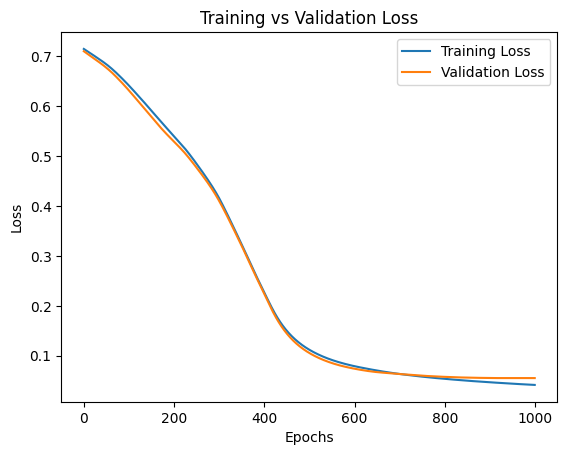

Validation Accuracy: 0.9825
Precision: 0.9859
F1 Score: 0.9859


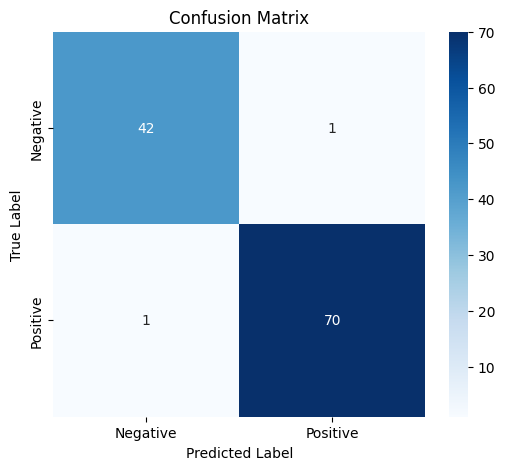

In [38]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Breast Cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target  # Features and labels

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Convert the data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # Add a dimension for compatibility
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

# Define the neural network model
class BreastCancerNN(nn.Module):
    def __init__(self, input_dim):
        super(BreastCancerNN, self).__init__()
        self.hidden1 = nn.Linear(input_dim, 32)  # Hidden layer with 32 nodes
        self.hidden2 = nn.Linear(32, 16)  # Hidden layer with 16 nodes
        self.hidden3 = nn.Linear(16, 8)  # Hidden layer with 16 nodes
        self.output = nn.Linear(8, 1)         # Output layer for binary classification

    def forward(self, x):
        x = torch.relu(self.hidden1(x))        # ReLU activation for the hidden1 layer
        x = torch.relu(self.hidden2(x))        # ReLU activation for the hidden2 layer
        x = torch.relu(self.hidden3(x))        # ReLU activation for the hidden3 layer

        x = torch.sigmoid(self.output(x))     # Sigmoid activation for binary classification
        return x

# Initialize the model
input_dim = X_train_tensor.shape[1]
model = BreastCancerNN(input_dim)

# Define the loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss for classification
optimizer = optim.Adam(model.parameters(), lr=0.0002)

# Training loop
num_epochs = 1000
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    optimizer.zero_grad()
    y_pred_train = model(X_train_tensor)
    train_loss = criterion(y_pred_train, y_train_tensor)
    train_loss.backward()
    optimizer.step()
    train_losses.append(train_loss.item())

    # Validation phase
    model.eval()
    with torch.no_grad():
        y_pred_val = model(X_val_tensor)
        val_loss = criterion(y_pred_val, y_val_tensor)
        val_losses.append(val_loss.item())

    # Print loss every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {train_loss.item():.4f}, Validation Loss: {val_loss.item():.4f}")

# Plot training and validation loss
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

# Evaluate the model on validation data
model.eval()
with torch.no_grad():
    y_pred_val = model(X_val_tensor)
    y_pred_classes = (y_pred_val > 0.5).float()  # Convert probabilities to binary predictions
    accuracy = (y_pred_classes == y_val_tensor).float().mean().item()
    print(f"Validation Accuracy: {accuracy:.4f}")

# Generate confusion matrix
y_true = y_val_tensor.numpy().flatten()  # Ground truth labels
y_pred = y_pred_classes.numpy().flatten()  # Predicted labels

conf_matrix = confusion_matrix(y_true, y_pred)

# Calculate precision and F1 score
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"F1 Score: {f1:.4f}")

# Plot confusion matrix with Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()